# Spike Stimuli Raster Comparison

This notebook generates a simulation campaign with the three spike stimulus types and plots their rasters:

1. **PoissonSpikeStimulus** - Spikes drawn from a homogeneous Poisson process
2. **SinusoidalPoissonSpikeStimulus** - Spikes from an inhomogeneous Poisson process with sinusoidal rate modulation
3. **FullySynchronousSpikeStimulus** - All source neurons fire simultaneously at each timestamp

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

import obi_one as obi

### Load Circuit

In [2]:
circuit_path_prefix = Path("../../../../data/tiny_circuits")
circuit_name = "N_10__top_nodes_dim6"
circuit = obi.Circuit(
    name=circuit_name,
    path=str(circuit_path_prefix / circuit_name / "circuit_config.json"),
)
pop = circuit.default_population_name
n_neurons = circuit.sonata_circuit.nodes[pop].size
print(f"Circuit '{circuit_name}' with {n_neurons} neurons (population: {pop})")

Circuit 'N_10__top_nodes_dim6' with 10 neurons (population: S1nonbarrel_neurons)


### Build Circuit Simulation Configuration

A single `CircuitSimulationScanConfig` with all three spike stimulus types.
Timestamps are repeated 3 times at 100, 600, and 1100 ms with a stimulus duration of 300 ms.

In [3]:
sim_length = 1500.0

sc = obi.CircuitSimulationScanConfig.empty_config()
sc.set(
    obi.Info(
        campaign_name="Spike Stimuli Comparison",
        campaign_description="Comparing spike stimulus types with raster visualization",
    ),
    name="info",
)

# Timestamps: 3 repetitions at t=100, 600, 1100 ms
timestamps = obi.RegularTimestamps(
    start_time=100.0, number_of_repetitions=3, interval=500.0,
)
sc.add(timestamps, name="stim_times")

# Neuron sets
source_ns = obi.AllNeurons()
target_ns = obi.AllNeurons()
sc.add(source_ns, name="source_neurons")
sc.add(target_ns, name="target_neurons")

# 1. Poisson Spike Stimulus
poisson = obi.PoissonSpikeStimulus(
    # source_neuron_set=source_ns.ref,
    targeted_neuron_set=target_ns.ref,
    timestamps=timestamps.ref,
    duration=300.0,
    frequency=20.0,
    random_seed=42,
)
sc.add(poisson, name="poisson")

# 2. Sinusoidal Poisson Spike Stimulus
sinusoidal = obi.SinusoidalPoissonSpikeStimulus(
    # source_neuron_set=source_ns.ref,
    targeted_neuron_set=target_ns.ref,
    timestamps=timestamps.ref,
    duration=300.0,
    minimum_rate=1.0,
    maximum_rate=20.0,
    modulation_frequency_hz=5.0,
    phase_degrees=0.0,
    random_seed=42,
)
sc.add(sinusoidal, name="sinusoidal")

# 3. Fully Synchronous Spike Stimulus
synchronous = obi.FullySynchronousSpikeStimulus(
    # source_neuron_set=source_ns.ref,
    targeted_neuron_set=target_ns.ref,
    timestamps=timestamps.ref,
)
sc.add(synchronous, name="synchronous")

# Initialize
init = obi.CircuitSimulationScanConfig.Initialize(
    circuit=[circuit],
    node_set=target_ns.ref,
    simulation_length=sim_length,
)
sc.set(init, name="initialize")

validated = sc.validated_config()
print("Configuration validated successfully")
print(f"Stimuli: {list(validated.stimuli.keys())}")

Configuration validated successfully
Stimuli: ['poisson', 'sinusoidal', 'synchronous']


### Generate Simulation Campaign

In [4]:
output_root = "../../../../../../../obi-output/spike_stimuli_raster"

grid_scan = obi.GridScanGenerationTask(form=validated, output_root=output_root)
grid_scan.multiple_value_parameters(display=True)
grid_scan.execute()
obi.run_task_for_single_configs(single_configs=grid_scan.single_configs)

[2026-03-27 15:34:12,558] INFO: 
MULTIPLE VALUE PARAMETERS
[2026-03-27 15:34:12,558] INFO: initialize.circuit: [Circuit(name='N_10__top_nodes_dim6', path='../../../../data/tiny_circuits/N_10__top_nodes_dim6/circuit_config.json', matrix_path=None, type='Circuit')]
[2026-03-27 15:34:12,561] INFO: initialize.circuit is a Circuit instance.


[None]

### Spike Raster Plots

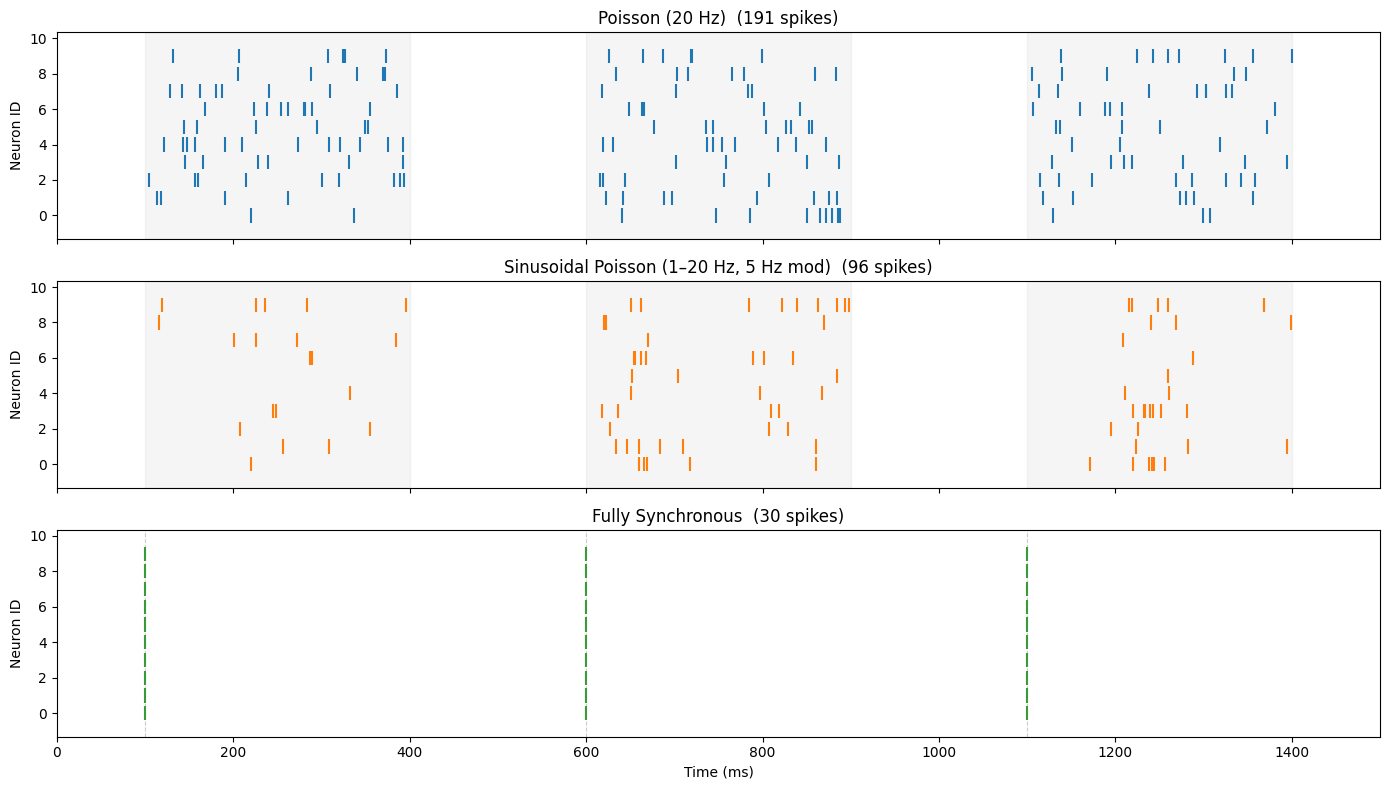

In [5]:
def read_spikes(spike_file):
    """Read spike times and neuron IDs from a SONATA spike file."""
    with h5py.File(spike_file, "r") as f:
        pop_name = list(f["spikes"].keys())[0]
        times = f[f"spikes/{pop_name}/timestamps"][:]
        gids = f[f"spikes/{pop_name}/node_ids"][:]
    return times, gids.astype(int)


coord_root = grid_scan.single_configs[0].coordinate_output_root
stim_info = {
    "poisson": {"title": "Poisson (20 Hz)", "color": "#1f77b4"},
    "sinusoidal": {"title": "Sinusoidal Poisson (1\u201320 Hz, 5 Hz mod)", "color": "#ff7f0e"},
    "synchronous": {"title": "Fully Synchronous", "color": "#2ca02c"},
}
timestamp_times = [100.0, 600.0, 1100.0]
stim_duration = 300.0

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, (name, info) in zip(axes, stim_info.items()):
    spike_file = coord_root / f"{name}_spikes.h5"
    times, gids = read_spikes(spike_file)

    # Raster plot
    unique_gids = sorted(set(gids))
    spike_trains = [times[gids == gid] for gid in unique_gids]
    ax.eventplot(
        spike_trains, lineoffsets=unique_gids, linelengths=0.8, colors=info["color"],
    )

    # Shade stimulus windows / mark timestamps
    for t in timestamp_times:
        if name == "synchronous":
            ax.axvline(t, color="gray", alpha=0.4, linestyle="--", linewidth=0.8)
        else:
            ax.axvspan(t, t + stim_duration, alpha=0.08, color="gray")

    ax.set_ylabel("Neuron ID")
    ax.set_title(f"{info['title']}  ({len(times)} spikes)")
    ax.set_xlim(0, sim_length)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()